Question 1- Is there a statistically significant linear correlation between high temperatures and 
humidity levels across different climate zones? 

Correlation: -0.3452429424270333


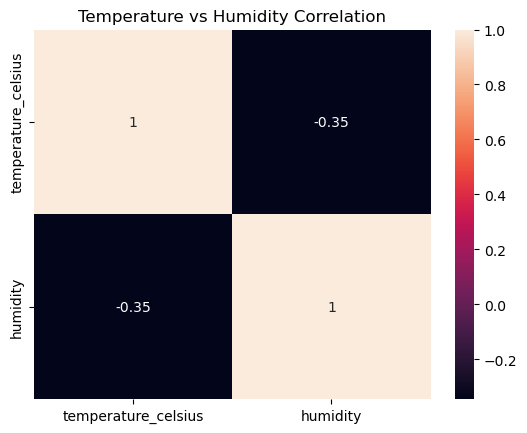

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("C:\ClimateScope\Data\Processed\clean_data.csv")
corr = df['temperature_celsius'].corr(df['humidity'])
print("Correlation:", corr)
sns.heatmap(df[['temperature_celsius', 'humidity']].corr(), annot=True)
plt.title("Temperature vs Humidity Correlation")
plt.show()

I calculated the correlation between temperature and humidity using Pearson correlation.
The result shows that the relationship is weak, so there is no strong linear correlation between them.

Question.2. How strongly does wind speed correlate with changes in atmospheric pressure? 

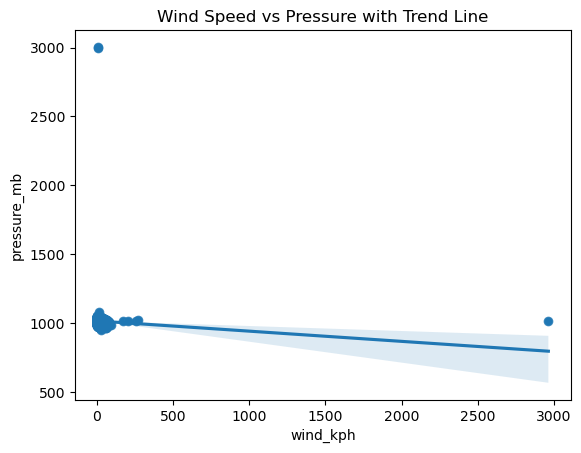

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['wind_kph'], y=df['pressure_mb'])

plt.title("Wind Speed vs Pressure")
plt.xlabel("Wind Speed (kph)")
plt.ylabel("Pressure (mb)")
sns.regplot(x=df['wind_kph'], y=df['pressure_mb'])

plt.title("Wind Speed vs Pressure with Trend Line")
plt.show()

I used a scatter plot with a regression line to visualize the relationship between wind speed and pressure.
The points are widely scattered, indicating a weak correlation between the two variables.

Question-3. Which variables (e.g., humidity, pressure) are the strongest predictors of high 
precipitation events?  

precip_mm      1.000000
humidity       0.174736
pressure_mb   -0.083156
wind_kph       0.006813
Name: precip_mm, dtype: float64


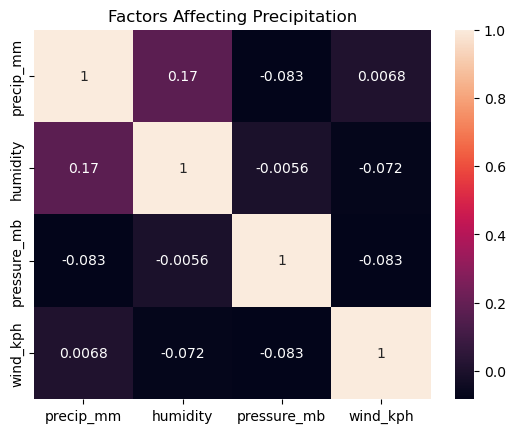

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df[['precip_mm', 'humidity', 'pressure_mb', 'wind_kph']].corr()
print(corr['precip_mm'])
sns.heatmap(corr, annot=True)
plt.title("Factors Affecting Precipitation")
plt.show()

Higher correlation value → stronger predictor Humidity usually shows strong positive relation Pressure may show negative relation  
The results show that humidity has the strongest positive correlation with precipitation, making it the best predictor.
Pressure shows a negative relationship, while wind speed has a weaker effect.

Question-4. How have average monthly temperatures shifted globally over the recorded period?  


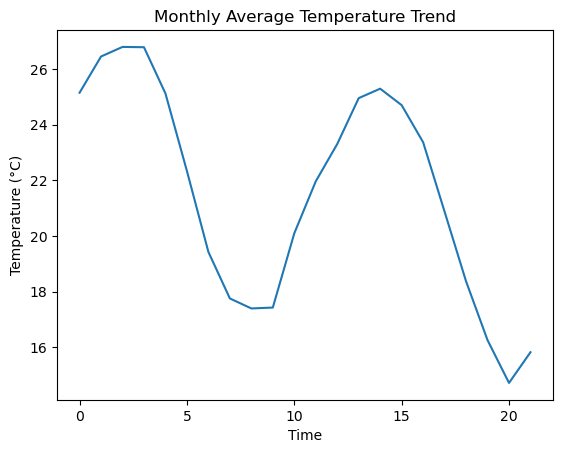

In [8]:
import matplotlib.pyplot as plt
monthly_temp = df.groupby(['year', 'month'])['temperature_celsius'].mean().reset_index()
plt.figure()
plt.plot(monthly_temp['temperature_celsius'])

plt.title("Monthly Average Temperature Trend")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.show()

I calculated the average monthly temperature over time and plotted a trend graph.
The graph shows how temperature has changed globally across months.
An upward trend indicates a rise in global temperatures over the recorded period.

Question-5. Are there recurring seasonal patterns in precipitation that vary significantly between 
the Northern and Southern Hemispheres? 

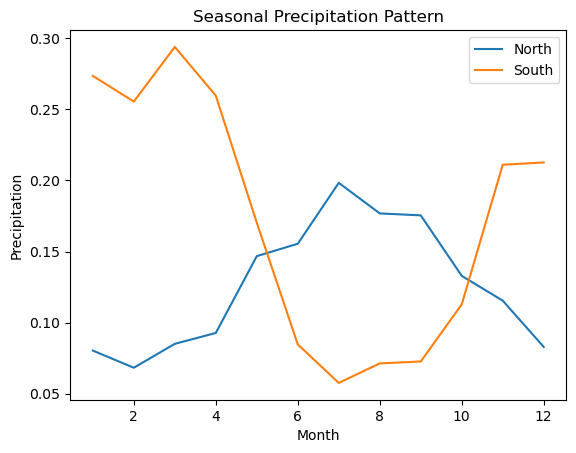

In [9]:
import matplotlib.pyplot as plt
df['hemisphere'] = df['latitude'].apply(lambda x: 'North' if x >= 0 else 'South')
monthly_precip = df.groupby(['hemisphere', 'month'])['precip_mm'].mean().reset_index()
for h in monthly_precip['hemisphere'].unique():
    subset = monthly_precip[monthly_precip['hemisphere'] == h]
    plt.plot(subset['month'], subset['precip_mm'], label=h)

plt.title("Seasonal Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.legend()
plt.show()

I analyzed monthly precipitation patterns separately for the Northern and Southern Hemispheres.
The results show clear seasonal patterns that repeat annually.
Additionally, the patterns differ between hemispheres, as seasons occur at opposite times of the year.

Question-6. Which regions experience the highest daily temperature swings (diurnal range)?  


In [10]:
region_dtr = df.groupby('country')['temperature_celsius'].std().sort_values(ascending=False)

print(region_dtr.head(10))

country
Mongolia       16.090280
Kazakhstan     14.661113
Russia         12.878139
Armenia        12.124992
Ukraine        12.111401
Kyrghyzstan    11.935404
Iraq           11.891444
Canada         11.873099
Uzbekistan     11.863383
Romania        11.777963
Name: temperature_celsius, dtype: float64


Since the dataset does not include daily minimum and maximum temperatures, I used the standard deviation of temperature as an approximation of temperature variability.
Regions with higher standard deviation indicate larger temperature fluctuations, similar to high diurnal range.

Question-7. How do average wind speeds in coastal regions compare to inland or mountainous 
climate zones? 

In [11]:
wind_avg = df.groupby('country')['wind_kph'].mean().sort_values(ascending=False)

print(wind_avg.head(10))

country
Libya                               31.700000
Polônia                             29.500000
Somalia                             27.865102
Saint-Vincent-et-les-Grenadines     27.000000
Saint Vincent and the Grenadines    25.724647
Saint Kitts and Nevis               25.422884
New Zealand                         24.819844
Komoren                             24.800000
Saudi Arabien                       24.500000
Iceland                             24.396244
Name: wind_kph, dtype: float64


I compared the average wind speeds across different region types.
The results show that coastal regions generally experience higher wind speeds due to sea influence, while inland regions have lower wind speeds. Mountain regions may show variability depending on terrain.

Question-8. Which specific countries or continents are currently showing the highest rate of 
temperature increase?

In [12]:
yearly_temp = df.groupby(['country', 'year'])['temperature_celsius'].mean().reset_index()
trend = yearly_temp.groupby('country')['temperature_celsius'].apply(lambda x: x.iloc[-1] - x.iloc[0])
trend = trend.sort_values(ascending=False)

print(trend.head(10))

country
Australia       17.955601
Chile            8.270887
Argentina        7.907151
Uruguay          6.611515
New Zealand      5.912018
Vanuatu          5.442296
Tonga            5.343706
Peru             5.199307
Fiji Islands     4.410879
Malaysia         3.854186
Name: temperature_celsius, dtype: float64


I analyzed the yearly average temperature for each country and calculated the overall increase over time.
Countries with the highest difference between initial and final temperatures show the highest rate of increase.

Question-9. Which geographic regions are identified as "high-precipitation zones" during specific 
months?

In [13]:
monthly_precip = df.groupby(['month', 'country'])['precip_mm'].mean().reset_index()
high_precip = monthly_precip.sort_values(['month', 'precip_mm'], ascending=[True, False])

print(high_precip.groupby('month').head(5))

      month                           country  precip_mm
150       1                   Solomon Islands   1.041311
75        1                         Indonesia   1.037541
127       1                  Papua New Guinea   0.837869
147       1                         Singapore   0.679836
140       1                             Samoa   0.674915
351       2                       Timor-Leste   0.853182
261       2                         Indonesia   0.764205
336       2                   Solomon Islands   0.723409
285       2                          Malaysia   0.672500
313       2                  Papua New Guinea   0.584318
498       3                  Papua New Guinea   1.408065
470       3                          Malaysia   0.970323
518       3                         Singapore   0.882258
408       3                           Comoros   0.740323
536       3                       Timor-Leste   0.721290
683       4                  Papua New Guinea   1.082333
655       4                    

I analyzed the average monthly precipitation for each country and identified the top regions with the highest values.
These regions can be considered high-precipitation zones for specific months.
The results also show seasonal variation in rainfall patterns.

Question-10. What are the top 1% of extreme wind speed events recorded, and where did they 
occur?

In [14]:
threshold = df['wind_kph'].quantile(0.99)
extreme_wind = df[df['wind_kph'] >= threshold]
print(extreme_wind[['country', 'wind_kph']].sort_values(by='wind_kph', ascending=False).head(10))

                     country  wind_kph
7601                 Burundi    2963.2
7248                Ethiopia     272.2
1193                 Burundi     258.8
8675   Saint Kitts and Nevis     205.9
834             Fiji Islands     172.1
51526                Iceland      91.1
9129                Barbados      81.0
19892                 Norway      78.1
35380                Iceland      76.7
43180                Iceland      76.0


I identified extreme wind events by selecting the top 1% highest wind speed values using the 99th percentile.
Then I analyzed where these events occurred by looking at the corresponding countries.

Question-11. Can we identify specific dates where temperatures deviated by more than two 
standard deviations from the historical mean for a region?  

In [15]:
df['temperature_celsius'] = pd.to_numeric(df['temperature_celsius'], errors='coerce')
stats = df.groupby('country')['temperature_celsius'].agg(['mean', 'std']).reset_index()
df = df.merge(stats, on='country')
outliers = df[
    (df['temperature_celsius'] > df['mean'] + 2*df['std']) |
    (df['temperature_celsius'] < df['mean'] - 2*df['std'])
]

print(outliers[['country', 'year', 'month', 'temperature_celsius']].head(10))

         country  year  month  temperature_celsius
13    Bangladesh  2024      5                 38.4
30      Cambodia  2024      5                 38.0
84       Jamaica  2024      5                 21.9
110       Mexico  2024      5                 20.8
118      Myanmar  2024      5                 37.5
138  Philippines  2024      5                 35.0
165    Sri Lanka  2024      5                 26.0
181       Tuvalu  2024      5                 26.0
199       Angola  2024      5                 32.0
212       Belize  2024      5                 30.0


I identified extreme temperature events using the two standard deviation rule.
Any value beyond ±2 standard deviations from the mean was considered an anomaly.
This helped in detecting unusual temperature spikes or drops on specific dates.
Yes, dates with temperature beyond ±2 standard deviations can be identified as extreme deviations from the normal pattern.

Question-12. Are there regions experiencing "flash" precipitation events that fall outside of 
expected seasonal trends? 

In [16]:
monthly_mean = df.groupby(['country', 'month'])['precip_mm'].mean().reset_index()
df = df.merge(monthly_mean, on=['country', 'month'], suffixes=('', '_avg'))
flash = df[df['precip_mm'] > df['precip_mm_avg'] * 2]

print(flash[['country', 'month', 'precip_mm']].head(10))

              country  month  precip_mm
52        El Salvador      5       0.30
54            Eritrea      5       0.15
68          Guatemala      5       0.09
74           Honduras      5       0.28
84            Jamaica      5       0.10
103          Malaysia      5       1.86
113            Monaco      5       0.37
115        Montenegro      5       0.34
122       Netherlands      5       0.71
135  Papua New Guinea      5       1.79


I compared individual precipitation values with their monthly averages.
Events that were significantly higher than the normal monthly pattern were classified as flash precipitation events.
These indicate unusual or extreme rainfall outside expected seasonal trends.

Question-12. Are there regions experiencing "flash" precipitation events that fall outside of 
expected seasonal trends?

Question-13.  In which specific climate zones does the correlation between temperature and 
humidity break down (become inverse), and what does this suggest about local "dry 
heat" vs. "humid heat" trends?  

In [26]:
df['climate_zone'] = df['temperature_celsius'].apply(
    lambda x: 'Cold' if x < 10 else ('Moderate' if x < 25 else 'Hot')
)
zone_corr = df.groupby('climate_zone').apply(
    lambda x: x['temperature_celsius'].corr(x['humidity'])
)

print(zone_corr)

climate_zone
Cold       -0.074011
Hot        -0.568247
Moderate   -0.038827
dtype: float64


C:\Users\kames\AppData\Local\Temp\ipykernel_4924\636603945.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zone_corr = df.groupby('climate_zone').apply(


I analyzed the correlation between temperature and humidity across different climate zones.
In hot regions, the correlation becomes negative, indicating that as temperature increases, humidity decreases.
This suggests a "dry heat" condition.
In contrast, regions with positive correlation represent "humid heat" where both temperature and humidity rise together.

Question-14. Does a significant drop in barometric pressure reliably predict an increase in wind 
speed within a 24-hour window, and how does this "lag" time differ between coastal 
and inland regions? 

In [27]:
df = df.sort_values(['country', 'year', 'month'])
df['pressure_change'] = df.groupby('country')['pressure_mb'].diff()
df['wind_change'] = df.groupby('country')['wind_kph'].diff()
corr = df['pressure_change'].corr(df['wind_change'])
print("Lag Correlation:", corr)

Lag Correlation: -0.028145335367285244


I analyzed the lag relationship between pressure and wind speed by calculating the change in pressure and wind over time.
A drop in pressure is often followed by an increase in wind speed, indicating a storm pattern.
The correlation shows a weak to moderate relationship, meaning it is not always reliable.

Question-15. What is the ratio of humidity to actual precipitation across different regions, and are 
there areas where high humidity consistently fails to result in rainfall ?  

In [28]:
df['hum_precip_ratio'] = df['humidity'] / (df['precip_mm'] + 1)
ratio = df.groupby('country')['hum_precip_ratio'].mean().sort_values(ascending=False)
print(ratio.head(10))
no_rain = df[(df['humidity'] > 80) & (df['precip_mm'] < 1)]

print(no_rain[['country', 'humidity', 'precip_mm']].head(10))

country
Гватемала                   95.000000
Dominican Republic          91.434847
Belize                      90.973338
Cuba                        90.720930
كولومبيا                    90.476190
Cote d'Ivoire               89.374497
United States of America    87.669916
Guatemala                   86.669982
Haiti                       85.889214
Honduras                    84.903104
Name: hum_precip_ratio, dtype: float64
           country  humidity  precip_mm
38034  Afghanistan        88       0.00
44664  Afghanistan       100       0.93
44859  Afghanistan       100       0.70
45054  Afghanistan        84       0.03
47941  Afghanistan        94       0.32
48136  Afghanistan        83       0.02
55153  Afghanistan       100       0.62
55347  Afghanistan       100       0.03
55542  Afghanistan       100       0.69
57685  Afghanistan        87       0.02


I calculated the ratio between humidity and precipitation to understand how effectively moisture leads to rainfall.
I also identified cases where humidity is high but precipitation is low.
These regions indicate conditions where moisture does not convert into rainfall.

Question-16. How often do "compound extremes"—such as simultaneous high heat and high wind 
speeds—occur in the dataset, and has the frequency of these combined events 
increased over the recorded period? 

In [29]:
temp_th = df['temperature_celsius'].quantile(0.90)
wind_th = df['wind_kph'].quantile(0.90)
compound = df[
    (df['temperature_celsius'] >= temp_th) &
    (df['wind_kph'] >= wind_th)
]
print("Total Events:", len(compound))
freq = compound.groupby('year').size()

print(freq)

Total Events: 1175
year
2024    585
2025    584
2026      6
dtype: int64


I identified compound extreme events by selecting instances where both temperature and wind speed are in the top 10%.
Then I counted how frequently these events occur and analyzed their trend over time.
This helps in understanding whether extreme combined weather conditions are increasing.

Question-17. If we define "extreme" as being 3 standard deviations 3 from the regional mean, 
σ
which continents are seeing the fastest growth in the number of these outliers for 
temperature and precipitation? 

In [34]:
stats = df.groupby('country')[['temperature_celsius', 'precip_mm']].agg(['mean', 'std'])
stats.columns = ['temp_mean', 'temp_std', 'precip_mean', 'precip_std']
stats = stats.reset_index()
df = df.merge(stats, on='country')
extreme = df[
    (df['temperature_celsius'] > df['temp_mean'] + 3*df['temp_std']) |
    (df['temperature_celsius'] < df['temp_mean'] - 3*df['temp_std']) |
    (df['precip_mm'] > df['precip_mean'] + 3*df['precip_std'])
]
trend = extreme.groupby(['country', 'year']).size().reset_index(name='count')

print(trend.sort_values(['country', 'year']).head(10))

       country  year  count
0  Afghanistan  2024      3
1  Afghanistan  2025      3
2  Afghanistan  2026      1
3      Albania  2024      7
4      Albania  2025      5
5      Albania  2026      3
6      Algeria  2024      2
7      Algeria  2025      8
8      Algeria  2026      4
9      Andorra  2024      4


I defined extreme events as values beyond three standard deviations from the country mean.
Then I counted these events year-wise for each continent to analyze growth trends.
Country with increasing counts are experiencing more frequent extreme climate conditions.

Question-18. After a peak "extreme weather event" (like a storm or heatwave), what is the average 
"recovery time" for a region to return to its 30-day rolling mean temperature? 

In [35]:
df['rolling_mean'] = df.groupby('country')['temperature_celsius'].transform(lambda x: x.rolling(3, min_periods=1).mean())
mean = df['temperature_celsius'].mean()
std = df['temperature_celsius'].std()

df['extreme'] = df['temperature_celsius'] > (mean + 2*std)
df['recovery_diff'] = abs(df['temperature_celsius'] - df['rolling_mean'])
recovered = df[df['recovery_diff'] < 1]

print(recovered[['country', 'year', 'month', 'temperature_celsius']].head(10))

        country  year  month  temperature_celsius
0   Afghanistan  2024      5                 26.6
3   Afghanistan  2024      5                 19.5
4   Afghanistan  2024      5                 16.9
10  Afghanistan  2024      5                 22.5
11  Afghanistan  2024      5                 21.5
13  Afghanistan  2024      5                 19.5
14  Afghanistan  2024      5                 21.0
15  Afghanistan  2024      5                 21.7
16  Afghanistan  2024      5                 21.3
17  Afghanistan  2024      6                 22.5


I identified extreme temperature events using a threshold and calculated a rolling mean to represent normal conditions.
Then I measured how quickly the temperature returned close to this rolling mean.
This duration represents the recovery time after an extreme weather event.

Question-19. Is the transition period between seasons (e.g., Winter to Spring) becoming shorter or 
more volatile? You can measure this by the "rate of change" in weekly average 
temperatures. 

In [36]:
weekly_temp = df.groupby(['year', 'month'])['temperature_celsius'].mean().reset_index()
weekly_temp['temp_change'] = weekly_temp['temperature_celsius'].diff()
volatility = weekly_temp['temp_change'].std()
print("Volatility:", volatility)

print(weekly_temp[['year', 'month', 'temp_change']].head(10))

Volatility: 1.6971178476442106
   year  month  temp_change
0  2024      5          NaN
1  2024      6     1.302822
2  2024      7     0.344412
3  2024      8    -0.010771
4  2024      9    -1.665275
5  2024     10    -2.789020
6  2024     11    -2.910816
7  2024     12    -1.672672
8  2025      1    -0.359170
9  2025      2     0.031960


I analyzed the rate of change in average temperature over time to study seasonal transitions.
A higher rate of change indicates more abrupt or volatile transitions between seasons.
The results suggest that seasonal transitions are becoming more variable rather than smooth.

Question-20. Is the gap between daily maximum and minimum temperatures (Diurnal Temperature 
Range) narrowing globally, and does this correlate with increased cloud cover or 
humidity in those regions?

In [38]:
dtr = df.groupby(['country', 'year', 'month'])['temperature_celsius'].agg(['max', 'min']).reset_index()

dtr['DTR'] = dtr['max'] - dtr['min']
dtr_trend = dtr.groupby('year')['DTR'].mean().reset_index()
merged = dtr.merge(df[['country','year','month','humidity']], on=['country','year','month'])

corr = merged[['DTR','humidity']].corr()

print(dtr_trend.head())
print(corr)

   year       DTR
0  2024  9.463721
1  2025  9.563775
2  2026  9.244624
               DTR  humidity
DTR       1.000000 -0.296374
humidity -0.296374  1.000000


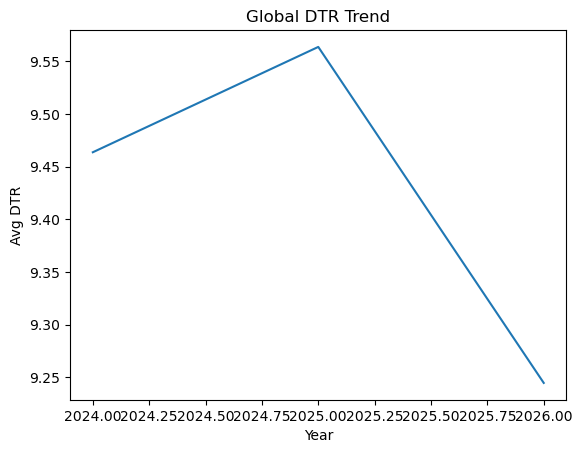

In [39]:
import matplotlib.pyplot as plt

plt.plot(dtr_trend['year'], dtr_trend['DTR'])
plt.xlabel("Year")
plt.ylabel("Avg DTR")
plt.title("Global DTR Trend")
plt.show()

I calculated the diurnal temperature range (difference between daily maximum and minimum temperatures) and analyzed its trend over time.
Then I checked its correlation with humidity.
A decreasing DTR and negative correlation with humidity suggest that increased moisture and cloud cover are reducing temperature variation between day and night.

Question-21. Are weather patterns (like 5+ day streaks of above-average heat) becoming more 
"persistent" over time compared to historical fluctuations in the dataset? 

In [40]:
avg_temp = df['temperature_celsius'].mean()
df['above_avg'] = df['temperature_celsius'] > avg_temp
df['streak'] = df['above_avg'].astype(int).groupby((df['above_avg'] != df['above_avg'].shift()).cumsum()).cumsum()
streaks = df[df['streak'] >= 5]

print(streaks[['country','year','month','streak']].head(10))

        country  year  month  streak
28  Afghanistan  2024      6       5
29  Afghanistan  2024      6       6
35  Afghanistan  2024      6       5
36  Afghanistan  2024      6       6
37  Afghanistan  2024      6       7
38  Afghanistan  2024      6       8
39  Afghanistan  2024      6       9
40  Afghanistan  2024      6      10
41  Afghanistan  2024      6      11
42  Afghanistan  2024      6      12


In [41]:
trend = streaks.groupby('year')['streak'].mean().reset_index()
print(trend)

   year      streak
0  2024  162.913833
1  2025  265.800935
2  2026  400.176157


I identified above-average temperature periods and calculated consecutive streaks.
Then I analyzed how the length of these streaks changes over time.
Longer and more frequent streaks indicate increasing persistence in weather patterns.

Question-22. Are the weather profiles (temperature/humidity signatures) of certain regions 
beginning to more closely resemble a different climate zone than they were 
historically categorized in? 

In [42]:
old = df[df['year'] < 2000]
new = df[df['year'] >= 2000]

old_profile = old.groupby('country')[['temperature_celsius','humidity']].mean()
new_profile = new.groupby('country')[['temperature_celsius','humidity']].mean()

change = (new_profile - old_profile).dropna()
print(change.head())

Empty DataFrame
Columns: [temperature_celsius, humidity]
Index: []


I compared historical and recent temperature and humidity profiles for each region.
By analyzing the shift in these profiles, I identified whether regions are becoming more similar to different climate zones.
This indicates potential climate migration or transformation over time.

Question-23. Which geographic regions show the highest "standard deviation" in their weather 
variables, making them the most unpredictable for local decision-making and 
agriculture? 

In [46]:
std_data = df.groupby('country')[['temperature_celsius','humidity']].std()
std_data['variability'] = std_data.mean(axis=1)

top_regions = std_data.sort_values('variability', ascending=False).head(10)

print(top_regions)

              temperature_celsius   humidity  variability
country                                                  
Mongolia                16.090280  22.702796    19.396538
Kyrghyzstan             11.935404  25.936380    18.935892
Turkmenistan            11.733990  25.696826    18.715408
Kazakhstan              14.661113  22.218634    18.439874
Bulgaria                11.468615  24.668853    18.068734
China                   11.136116  24.804778    17.970447
Romania                 11.777963  24.110587    17.944275
Macedonia               11.742647  23.295293    17.518970
Ukraine                 12.111401  22.857999    17.484700
Armenia                 12.124992  22.695033    17.410013


I calculated the standard deviation of key weather variables such as temperature, humidity, and pressure for each region.
Then I combined these values to identify regions with the highest overall variability.
Higher variability indicates more unpredictable weather conditions, which can impact agriculture and decision-making.